# ANOVA says something differs. Which pair?

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/anova-posthoc/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/anova-posthoc/demo.ipynb)

A significant F says the k group means are not all equal. It does not say which pair differs, and
there are k(k-1)/2 pairs to hunt through. Five procedures do the hunting - no adjustment, Fisher's
protected LSD, Bonferroni, Holm, Tukey's HSD - and this notebook measures what each one costs.

1. Calibration - against scipy, and three identities counted
2. All means equal - the family-wise false-alarm rate as k grows
3. One group far away - where "protected" LSD stops protecting
4. Power - Tukey vs Holm, as a paired difference with its own noise
5. "Something differs" and nothing the post-hoc test will name
6. One dataset, five answers
7. Try your own

## The engine

Extracted from `posthoc.py` at build time, character for character.

In [1]:
from __future__ import annotations

from typing import Dict, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

ALPHA = 0.05


PROCS = ("none", "lsd", "bonferroni", "holm", "tukey")


LABEL = {"none": "no adjustment", "lsd": "protected LSD", "bonferroni": "Bonferroni",
         "holm": "Holm", "tukey": "Tukey HSD"}


BAND_LO, BAND_HI = 0.045, 0.055


Z99 = 2.5758293035489


N_PER_GROUP = 20


REPS = 20_000


KS = (3, 4, 5, 6, 8, 10)


NULL_DESIGNS: List[Tuple[int, str, float]] = [(k, "null", 0.0) for k in KS]


PARTIAL_DESIGNS: List[Tuple[int, str, float]] = [(k, "one-out", 3.0) for k in KS]


POWER_DESIGNS: List[Tuple[int, str, float]] = (
    [(k, "one-out", 0.9) for k in (3, 5, 8)] + [(k, "spread", 1.0) for k in (3, 5, 8, 10)]
)


SEED_BASE = {"null": 1_000, "partial": 2_000, "power": 3_000}


def wilson(hits: int, n: int, z: float = Z99) -> Tuple[float, float]:
    if n == 0:
        return (0.0, 1.0)
    p = hits / n
    den = 1.0 + z * z / n
    mid = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return (float(mid - half), float(mid + half))


def verdict(hits: int, n: int) -> str:
    lo, hi = wilson(hits, n)
    if lo > BAND_HI:
        return "INFLATED"
    if hi < BAND_LO:
        return "CONSERVATIVE"
    return "ok"


def means_for(k: int, shape: str, effect: float) -> np.ndarray:
    """True group means in SD units. `one-out`: one group shifted by `effect`, the rest at 0.
    `spread`: means evenly spaced from 0 to `effect` - a ladder, where every pair differs."""
    if shape == "null":
        return np.zeros(k)
    if shape == "one-out":
        mu = np.zeros(k)
        mu[0] = effect
        return mu
    if shape == "spread":
        return np.linspace(0.0, effect, k)
    raise ValueError(shape)


def pairs(k: int) -> List[Tuple[int, int]]:
    return [(i, j) for i in range(k) for j in range(i + 1, k)]


def summarise(data: np.ndarray) -> Tuple[np.ndarray, np.ndarray, int]:
    """data (reps, k, n) -> group means (reps, k), pooled MSE (reps,), error df."""
    reps, k, n = data.shape
    m = data.mean(axis=2)
    mse = ((data - m[:, :, None]) ** 2).sum(axis=(1, 2)) / (k * (n - 1))
    return m, mse, k * (n - 1)


def f_pvalue(m: np.ndarray, mse: np.ndarray, n: int) -> np.ndarray:
    k = m.shape[1]
    msb = n * ((m - m.mean(axis=1, keepdims=True)) ** 2).sum(axis=1) / (k - 1)
    return stats.f.sf(msb / mse, k - 1, k * (n - 1))


def pair_t(m: np.ndarray, mse: np.ndarray, n: int) -> np.ndarray:
    """Pooled-MSE t statistic for every pair, shape (reps, m)."""
    idx = pairs(m.shape[1])
    diff = np.stack([m[:, i] - m[:, j] for i, j in idx], axis=1)
    return diff / np.sqrt(2.0 * mse / n)[:, None]


_QCRIT: Dict[Tuple[int, int, float], float] = {}


def q_crit(k: int, df: int, alpha: float = ALPHA) -> float:
    """Studentized-range critical value. Slow in scipy, so computed once per (k, df)."""
    key = (k, df, alpha)
    if key not in _QCRIT:
        _QCRIT[key] = float(stats.studentized_range.ppf(1.0 - alpha, k, df))
    return _QCRIT[key]


def holm_reject(p: np.ndarray, alpha: float = ALPHA) -> np.ndarray:
    """Step-down Holm, vectorised over rows. Reject the smallest p while p_(r) <= alpha/(m-r)."""
    m = p.shape[1]
    order = np.argsort(p, axis=1)
    ps = np.take_along_axis(p, order, axis=1)
    passed = np.cumprod(ps <= alpha / (m - np.arange(m)), axis=1).astype(bool)
    out = np.zeros_like(passed)
    np.put_along_axis(out, order, passed, axis=1)
    return out


def decisions(data: np.ndarray, alpha: float = ALPHA) -> Dict[str, np.ndarray]:
    """Every procedure's pairwise rejections, each (reps, m) bool, plus the omnibus F p-value."""
    m, mse, df = summarise(data)
    n = data.shape[2]
    k = m.shape[1]
    t = pair_t(m, mse, n)
    p = 2.0 * stats.t.sf(np.abs(t), df)
    pf = f_pvalue(m, mse, n)
    npairs = p.shape[1]
    return {
        "F": pf,
        "none": p < alpha,
        "lsd": (pf < alpha)[:, None] & (p < alpha),
        "bonferroni": p < alpha / npairs,
        "holm": holm_reject(p, alpha),
        # |t| * sqrt(2) is the studentized range statistic for one pair with equal n
        "tukey": np.abs(t) * np.sqrt(2.0) > q_crit(k, df, alpha),
    }


def simulate(k: int, shape: str, effect: float, seed: int, reps: int = REPS,
             n: int = N_PER_GROUP) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.standard_normal((reps, k, n)) + means_for(k, shape, effect)[None, :, None]


def run_design(k: int, shape: str, effect: float, seed: int, reps: int = REPS,
               n: int = N_PER_GROUP) -> Dict[str, object]:
    mu = means_for(k, shape, effect)
    idx = pairs(k)
    null_pairs = np.array([mu[i] == mu[j] for i, j in idx])
    dec = decisions(simulate(k, shape, effect, seed, reps, n))
    f_sig = dec["F"] < ALPHA
    row: Dict[str, object] = {"k": k, "shape": shape, "effect": effect, "reps": reps, "seed": seed,
                              "pairs": len(idx), "null_pairs": int(null_pairs.sum()),
                              "F_sig": float(f_sig.mean())}
    if (~null_pairs).any():
        # Tukey vs Holm per-pair power as a PAIRED difference on the same replicates, so the gap is
        # read against its own noise: material only if it clears a 99% interval (the Day 176 rule
        # that a win/loss tally without a materiality threshold counts coin flips).
        gap = dec["tukey"][:, ~null_pairs].mean(axis=1) - dec["holm"][:, ~null_pairs].mean(axis=1)
        half = Z99 * gap.std(ddof=1) / np.sqrt(reps)
        row["tukey_minus_holm"] = float(gap.mean())
        row["tukey_minus_holm_half"] = float(half)
        row["tukey_vs_holm"] = ("tukey" if gap.mean() > half else
                                "holm" if gap.mean() < -half else "tie")
    for proc in PROCS:
        d = dec[proc]
        if null_pairs.any():
            hits = int(d[:, null_pairs].any(axis=1).sum())
            row[f"{proc}_fwer"] = hits / reps
            row[f"{proc}_fwer_ci"] = wilson(hits, reps)
            row[f"{proc}_fwer_verdict"] = verdict(hits, reps)
        if (~null_pairs).any():
            row[f"{proc}_any"] = float(d[:, ~null_pairs].any(axis=1).mean())
            row[f"{proc}_per_pair"] = float(d[:, ~null_pairs].mean())
            row[f"{proc}_all"] = float(d[:, ~null_pairs].all(axis=1).mean())
        found = d.any(axis=1)
        # "ANOVA says something differs, but this procedure names no pair" - and the reverse
        row[f"{proc}_F_sig_no_pair"] = float((f_sig & ~found).mean())
        row[f"{proc}_pair_no_F"] = float((~f_sig & found).mean())
        row[f"{proc}_no_pair_given_F"] = float((f_sig & ~found).sum() / max(int(f_sig.sum()), 1))
    return row


def null_table(reps: int = REPS) -> List[Dict[str, object]]:
    return [run_design(k, s, e, SEED_BASE["null"] + i, reps) for i, (k, s, e) in enumerate(NULL_DESIGNS)]


def partial_table(reps: int = REPS) -> List[Dict[str, object]]:
    return [run_design(k, s, e, SEED_BASE["partial"] + i, reps)
            for i, (k, s, e) in enumerate(PARTIAL_DESIGNS)]


def power_table(partial: Sequence[Dict[str, object]], reps: int = REPS) -> List[Dict[str, object]]:
    """Power, gated: a procedure is COMPARABLE at k only if its FWER on the partial-null design at
    the same k is not INFLATED. An inflated procedure 'finds more' because it rejects more of
    everything, so its power lead is the inflation restated (the Day 176 rule)."""
    inflated = {(r["k"], p) for r in partial for p in PROCS if r[f"{p}_fwer_verdict"] == "INFLATED"}
    rows = []
    for i, (k, s, e) in enumerate(POWER_DESIGNS):
        r = run_design(k, s, e, SEED_BASE["power"] + i, reps)
        for p in PROCS:
            r[f"{p}_comparable"] = (k, p) not in inflated
        rows.append(r)
    return rows


def identity_checks(reps: int = 20_000, seed: int = 99) -> Dict[str, int]:
    """Logical statements that must hold on EVERY replicate, counted rather than assumed.

    1. Holm rejects every pair Bonferroni rejects (its first step IS Bonferroni).
    2. Under the complete null, Holm rejects anything iff Bonferroni does - so their FWER is
       identical there by construction, and Holm's advantage can only show up as power.
    3. Protected LSD never rejects a pair without a significant F (the protection, by definition).
    """
    out = {"holm_misses_bonferroni_pair": 0, "holm_vs_bonferroni_any_differs_under_null": 0,
           "lsd_without_F": 0, "replicates": 0}
    for i, k in enumerate(KS):
        dec = decisions(simulate(k, "null", 0.0, seed + i, reps))
        out["holm_misses_bonferroni_pair"] += int((dec["bonferroni"] & ~dec["holm"]).sum())
        out["holm_vs_bonferroni_any_differs_under_null"] += int(
            (dec["bonferroni"].any(axis=1) != dec["holm"].any(axis=1)).sum())
        out["lsd_without_F"] += int((dec["lsd"].any(axis=1) & (dec["F"] >= ALPHA)).sum())
        out["replicates"] += reps
    return out


def calibrate_against_scipy(trials: int = 300, seed: int = 7) -> Dict[str, float]:
    """Our Tukey decisions vs scipy.stats.tukey_hsd, and our F vs scipy.stats.f_oneway."""
    rng = np.random.default_rng(seed)
    mismatches, f_gap, compared = 0, 0.0, 0
    for t in range(trials):
        k = KS[t % len(KS)]
        data = rng.standard_normal((1, k, N_PER_GROUP)) + rng.normal(0, 0.4, k)[None, :, None]
        dec = decisions(data)
        groups = [data[0, g] for g in range(k)]
        ref = stats.tukey_hsd(*groups).pvalue
        for c, (i, j) in enumerate(pairs(k)):
            mismatches += int(bool(dec["tukey"][0, c]) != bool(ref[i, j] < ALPHA))
            compared += 1
        f_gap = max(f_gap, abs(float(dec["F"][0]) - stats.f_oneway(*groups).pvalue))
    return {"tukey_decision_mismatches": mismatches, "pairs_compared": compared,
            "max_F_p_gap": f_gap}


def analyse(groups: Sequence[Sequence[float]], alpha: float = ALPHA) -> Dict[str, object]:
    """One real dataset (unequal n allowed): F, and each procedure's list of significant pairs.

    Unequal n uses Tukey-Kramer via scipy.stats.tukey_hsd and a per-pair pooled-MSE SE for the rest.
    Edge case: a group with fewer than 2 values has no variance and is rejected up front."""
    arrs = [np.asarray(g, dtype=float) for g in groups]
    if len(arrs) < 3:
        raise ValueError("need at least 3 groups for a post-hoc question")
    if any(a.size < 2 for a in arrs):
        raise ValueError("every group needs at least 2 values")
    k = len(arrs)
    ns = np.array([a.size for a in arrs])
    means = np.array([a.mean() for a in arrs])
    df = int(ns.sum() - k)
    mse = sum(((a - a.mean()) ** 2).sum() for a in arrs) / df
    idx = pairs(k)
    p = np.array([2.0 * stats.t.sf(abs(means[i] - means[j]) / np.sqrt(mse * (1 / ns[i] + 1 / ns[j])), df)
                  for i, j in idx])[None, :]
    pf = float(stats.f_oneway(*arrs).pvalue)
    tk = stats.tukey_hsd(*arrs).pvalue
    rej = {
        "none": p[0] < alpha,
        "lsd": (p[0] < alpha) & (pf < alpha),
        "bonferroni": p[0] < alpha / len(idx),
        "holm": holm_reject(p, alpha)[0],
        "tukey": np.array([tk[i, j] < alpha for i, j in idx]),
    }
    return {"F_p": pf, "means": means.tolist(), "pairs": idx, "raw_p": p[0].tolist(),
            "tukey_p": [float(tk[i, j]) for i, j in idx],
            "significant": {proc: [idx[c] for c in np.flatnonzero(rej[proc])] for proc in PROCS}}


def exemplar(k: int = 5, effect: float = 1.0, max_seed: int = 10_000) -> Dict[str, object]:
    """Chosen by RULE, not by hand: the first seed of a k-group ladder where the F test is
    significant and Tukey names no pair, while an unadjusted pair list names at least one."""
    for seed in range(max_seed):
        data = simulate(k, "spread", effect, seed, reps=1)
        groups = [np.round(data[0, g], 2).tolist() for g in range(k)]
        res = analyse(groups)
        if res["F_p"] < ALPHA and not res["significant"]["tukey"] and res["significant"]["none"]:
            return {"seed": seed, "k": k, "effect": effect, "groups": groups, **res}
    raise RuntimeError("no exemplar found")

print('engine loaded')

engine loaded


**Resolution of the instrument.** The study behind the README runs 20,000 replicates per design.
This notebook runs 4,000 with the SAME seeds, so every Wilson interval is about 2.2x wider:
a cell the study calls CONSERVATIVE can read `ok` here. That is lower resolution, not
disagreement - `evidence.txt` is the reference.

## 1. Calibration

In [2]:
print(calibrate_against_scipy())
print(identity_checks(reps=2000))

{'tukey_decision_mismatches': 0, 'pairs_compared': 5350, 'max_F_p_gap': 7.771561172376096e-16}
{'holm_misses_bonferroni_pair': 0, 'holm_vs_bonferroni_any_differs_under_null': 0, 'lsd_without_F': 0, 'replicates': 12000}


Tukey's decisions match `scipy.stats.tukey_hsd` pair for pair. Holm never misses a pair Bonferroni
finds, and under the complete null the two agree on *whether anything* is significant on every
replicate - so their family-wise error is identical there by construction. Holm's advantage can
only ever show up as power.

## 2. All means equal

Every "significant pair" is a false alarm. FWER = P(at least one pair called).

In [3]:
NB_REPS = 4000
null = null_table(NB_REPS)
print("  k " + "".join(f"{LABEL[p]:>16}" for p in PROCS))
for r in null:
    print(f"{r['k']:>3} " + "".join(f"{r[p + '_fwer']:>9.4f} {r[p + '_fwer_verdict'][:5]:<6}" for p in PROCS))

  k    no adjustment   protected LSD      Bonferroni            Holm       Tukey HSD
  3    0.1222 INFLA    0.0525 ok       0.0445 ok       0.0445 ok       0.0510 ok    
  4    0.1965 INFLA    0.0535 ok       0.0425 ok       0.0425 ok       0.0510 ok    
  5    0.2765 INFLA    0.0500 ok       0.0393 ok       0.0393 ok       0.0483 ok    
  6    0.3533 INFLA    0.0480 ok       0.0367 ok       0.0367 ok       0.0505 ok    
  8    0.5028 INFLA    0.0493 ok       0.0318 CONSE    0.0318 CONSE    0.0430 ok    
 10    0.6232 INFLA    0.0550 ok       0.0367 ok       0.0367 ok       0.0527 ok    


With no adjustment the family calls a winner more than half the time by k = 8. Tukey sits on 5% at
every k - it is exact for this setting, so it doubles as the harness's calibration line.
Bonferroni and Holm run BELOW 5% as k grows: the pairwise tests share group means and are
correlated, and Bonferroni's bound assumes the worst case.

## 3. One group far away

One group 3 SD from the rest, so the F test fires on essentially every replicate, and the
remaining k-1 groups are exactly equal. Any pair among them that gets called is a false alarm.

In [4]:
partial = partial_table(NB_REPS)
print("  k  F sig " + "".join(f"{LABEL[p]:>16}" for p in PROCS))
for r in partial:
    print(f"{r['k']:>3} {r['F_sig']:>6.3f} " + "".join(f"{r[p + '_fwer']:>9.4f} {r[p + '_fwer_verdict'][:5]:<6}" for p in PROCS))

  k  F sig    no adjustment   protected LSD      Bonferroni            Holm       Tukey HSD
  3  1.000    0.0512 ok       0.0512 ok       0.0182 CONSE    0.0512 ok       0.0195 CONSE 
  4  1.000    0.1195 INFLA    0.1195 INFLA    0.0210 CONSE    0.0393 ok       0.0253 CONSE 
  5  1.000    0.1993 INFLA    0.1993 INFLA    0.0255 CONSE    0.0410 ok       0.0330 CONSE 
  6  1.000    0.2953 INFLA    0.2953 INFLA    0.0333 CONSE    0.0470 ok       0.0423 ok    
  8  1.000    0.4253 INFLA    0.4253 INFLA    0.0293 CONSE    0.0350 CONSE    0.0362 CONSE 
 10  1.000    0.5623 INFLA    0.5623 INFLA    0.0265 CONSE    0.0318 CONSE    0.0357 CONSE 


Protected LSD is the "no adjustment" column exactly: once the F test has fired on the obvious group,
the protection is spent and every other pair is tested at a raw 0.05. It holds only at k = 3, where
one null pair is left. This is the textbook result that LSD controls family-wise error in the
*weak* sense (complete null) and not the *strong* sense (any configuration).

## 4. Power

Per-pair power = share of truly different pairs a procedure names. A procedure is compared only if
its FWER in section 3 is not INFLATED at that k - otherwise its lead is the inflation restated
(marked `*`). Tukey minus Holm is a PAIRED difference on the same replicates, called a win only if
it clears its own 99% interval.

In [5]:
power = power_table(partial, NB_REPS)
print("design        " + "".join(f"{LABEL[p]:>16}" for p in PROCS) + "   Tukey-Holm   winner")
for r in power:
    print(f"k={r['k']:>2} {r['shape']:<8}" + "".join(f"{r[p + '_per_pair']:>15.4f}{' ' if r[p + '_comparable'] else '*'}" for p in PROCS)
          + f"   {r['tukey_minus_holm']:+.4f}     {r['tukey_vs_holm']}")

design           no adjustment   protected LSD      Bonferroni            Holm       Tukey HSD   Tukey-Holm   winner
k= 3 one-out          0.7960          0.7510          0.6496          0.6825          0.6686    -0.0139     holm
k= 5 one-out          0.8013*         0.7196*         0.4821          0.5047          0.5188    +0.0141     tukey
k= 8 one-out          0.8011*         0.6875*         0.3719          0.3833          0.4100    +0.0267     tukey
k= 3 spread           0.5178          0.4838          0.3800          0.4224          0.3961    -0.0263     holm
k= 5 spread           0.3706*         0.3435*         0.1636          0.1769          0.1803    +0.0034     tukey
k= 8 spread           0.3143*         0.2977*         0.0852          0.0891          0.0979    +0.0088     tukey
k=10 spread           0.2950*         0.2818*         0.0626          0.0650          0.0730    +0.0080     tukey


Tukey beats Holm from k = 5 up; at k = 3 Holm wins. With only three pairs Holm's step-down
thresholds (0.0167, 0.025, 0.05) are generous, and the studentized-range penalty is not yet paid
back. "Always use Tukey" and "Holm is uniformly better than Bonferroni" are both true - and Holm
still loses to Tukey at the k most people have.

## 5. Something differs - and no pair is named

On the ladder designs every pair truly differs. How often is F significant while the post-hoc
procedure names nothing?

k= 3  P(F sig) 0.794   P(no Tukey pair | F sig) 0.017   P(no Holm pair | F sig) 0.031   P(Tukey pair, F not sig) 0.013
k= 5  P(F sig) 0.804   P(no Tukey pair | F sig) 0.063   P(no Holm pair | F sig) 0.091   P(Tukey pair, F not sig) 0.018
k= 8  P(F sig) 0.867   P(no Tukey pair | F sig) 0.097   P(no Holm pair | F sig) 0.145   P(Tukey pair, F not sig) 0.015
k=10  P(F sig) 0.890   P(no Tukey pair | F sig) 0.099   P(no Holm pair | F sig) 0.141   P(Tukey pair, F not sig) 0.012


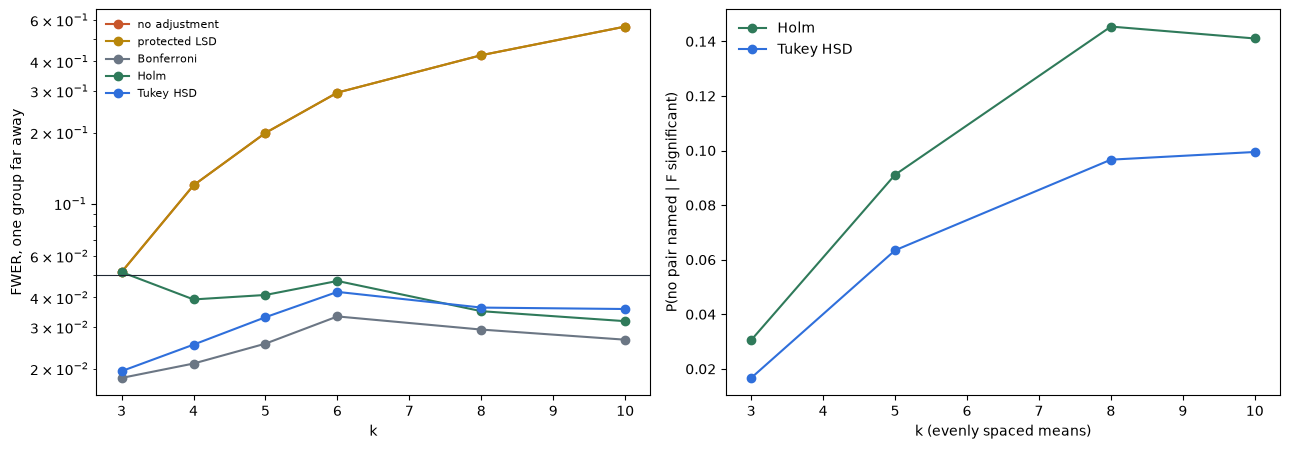

In [6]:
spread = [r for r in power if r["shape"] == "spread"]
for r in spread:
    print(f"k={r['k']:>2}  P(F sig) {r['F_sig']:.3f}   P(no Tukey pair | F sig) {r['tukey_no_pair_given_F']:.3f}"
          f"   P(no Holm pair | F sig) {r['holm_no_pair_given_F']:.3f}   P(Tukey pair, F not sig) {r['tukey_pair_no_F']:.3f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
ks = [r["k"] for r in null]
cols = {"none": "#c8562b", "lsd": "#b8860b", "bonferroni": "#6b7684", "holm": "#2f7a5a", "tukey": "#2f6fdb"}
for p in PROCS:
    a1.plot(ks, [r[p + "_fwer"] for r in partial], marker="o", color=cols[p], label=LABEL[p])
a1.axhline(ALPHA, color="#1f2733", lw=0.8)
a1.set_yscale("log")
a1.set_xlabel("k")
a1.set_ylabel("FWER, one group far away")
a1.legend(frameon=False, fontsize=8)
for p in ("holm", "tukey"):
    a2.plot([r["k"] for r in spread], [r[p + "_no_pair_given_F"] for r in spread], marker="o", color=cols[p], label=LABEL[p])
a2.set_xlabel("k (evenly spaced means)")
a2.set_ylabel("P(no pair named | F significant)")
a2.legend(frameon=False)
plt.tight_layout()
plt.savefig("notebook_chart.png", dpi=150)
plt.show()

The two answers disagree in both directions. F can be significant with no nameable pair (the
evidence is spread across a contrast no single pair captures), and Tukey can name a pair while F is
not significant. So "run the F test first, and only then the post-hoc" silently discards some
real Tukey findings - Tukey controls family-wise error on its own and does not need the gate.

## 6. One dataset, five answers

Chosen by rule: the first seed of a 5-group ladder where F is significant, Tukey names nothing, and
unadjusted t-tests name at least one pair.

In [7]:
ex = exemplar()
print(f"seed {ex['seed']}   group means " + ", ".join(f"{m:.2f}" for m in ex["means"]) + f"   F p = {ex['F_p']:.4f}")
for p in PROCS:
    print(f"  {LABEL[p]:<16} " + (", ".join(f"{chr(65+i)}-{chr(65+j)}" for i, j in ex["significant"][p]) or "none"))

seed 2   group means -0.05, 0.31, 0.73, 0.68, 0.79   F p = 0.0335
  no adjustment    A-C, A-D, A-E
  protected LSD    A-C, A-D, A-E
  Bonferroni       none
  Holm             none
  Tukey HSD        none


## Summary

| | |
|---|---|
| **No adjustment** | FWER 0.12 at k = 3 up to 0.62 at k = 10 |
| **Protected LSD** | fine when all means are equal; inflated at every k >= 4 once one group is clearly different |
| **Bonferroni / Holm** | identical FWER under the complete null; both conservative as k grows |
| **Tukey HSD** | exact FWER; beats Holm on power from k = 5, loses to it at k = 3 |
| **F vs post-hoc** | F significant with no Tukey pair up to about 1 in 9 at k = 10 |

For all-pairs comparisons with roughly equal n: **Tukey**, without waiting for the F gate. At k = 3,
Holm is the more powerful choice. Never protected LSD beyond three groups.

## Try your own

In [8]:
# groups = [
#     [12.1, 11.8, 13.0, 12.4, 12.9],
#     [13.2, 13.8, 12.9, 14.1, 13.5],
#     [12.0, 12.6, 11.9, 12.3, 12.8],
#     [14.0, 13.7, 14.4, 13.9, 14.6],
# ]
# res = analyse(groups)
# print("F p =", round(res["F_p"], 4))
# for p in PROCS:
#     print(LABEL[p], res["significant"][p])
print("uncomment to explore")

uncomment to explore


---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](data-science-cookbook/anova-posthoc)

Streamlit version, where you paste your own groups:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Sibling builds: [`t-test-variants`](../t-test-variants) audited the two-group case;
[`stat-test-advisor`](../stat-test-advisor) picks a test; [`p-value-dance`](../p-value-dance)
measured the winner's curse that a family of pairwise tests multiplies.